# CCD Lookup Example

![CCD Lookup Example](https://proto-bio.github.io/proto-assets/images/tool/ccd_lookup/hero.png)

`ccd-lookup` wraps [`pdbeccdutils`](https://github.com/PDBeurope/ccdutils) for rich enrichment of wwPDB Chemical Component Dictionary entries.

- **Inputs:** CCD codes (e.g. `ATP`) or SMILES strings (auto-detected).
- **Defaults:** fully offline.
- **Optional network features:** UniChem cross-references and PDB usage.

For the microsecond-latency hot path used by Fragment validation, see the in-process `proto_tools.entities.ligands.ccd_utils` module instead.

In [1]:
from proto_tools.tools.database_retrieval.ccd_lookup import (
    run_ccd_lookup,
    CcdLookupInput,
    CcdLookupConfig,
)

In [2]:
from proto_tools.utils.notebook_docs import display_api_reference

In [3]:
# Display input docs
display_api_reference("ccd_lookup", "input")

**Input** — `CcdLookupInput`

| Field | Type | Default | Description |
|-------|------|---------|-------------|
| <code>identifiers</code> | <code>list[str]</code> | required | CCD codes (e.g. 'ATP') or SMILES strings to enrich |

In [4]:
# Display config docs
display_api_reference("ccd_lookup", "config")

**Config** — `CcdLookupConfig`

| Field | Type | Default | Description |
|-------|------|---------|-------------|
| <code>verbose</code> | <code>int</code> | <code>0</code> | Verbosity level (0=quiet, 1=info, 2=debug, 3=raw subprocess stderr). True→1, False→0. |
| <code>device</code> | <code>str</code> | <code>'cpu'</code> | Device to run the tool on (e.g., 'cpu', 'cuda', 'cuda:0', 'cloud') |
| <code>timeout</code> | <code>int &#124; None</code> | <code>3600</code> | Maximum execution time in seconds. None waits indefinitely. |
| <code>seed</code> | <code>int &#124; None</code> | <code>None</code> | Random seed for reproducible results. Some cacheable tools gate cache on this field. |
| <code>include_cross_references</code> | <code>bool</code> | <code>False</code> | Fetch UniChem cross-references (network, opt-in) |
| <code>include_pdb_usage</code> | <code>bool</code> | <code>False</code> | Fetch PDB structures containing this ligand (network, opt-in) |
| <code>sanitize</code> | <code>bool</code> | <code>True</code> | Sanitize the parsed RDKit molecule |

In [5]:
# Display output docs
display_api_reference("ccd_lookup", "output")

**Output** — `CcdLookupOutput`

| Field | Type | Default | Description |
|-------|------|---------|-------------|
| <code>ligands</code> | <code>Ligands</code> | <code>Ligands(fragments=[])</code> | Resolved fragments, one per input identifier (in input order) |
| <code>enrichments</code> | <code>list[CcdEnrichment]</code> | <code>[]</code> | Per-identifier CCD enrichment metadata, parallel to ligands.fragments |

**`CcdEnrichment`**

| Field | Type | Default | Description |
|-------|------|---------|-------------|
| <code>ccd_code</code> | <code>str &#124; None</code> | <code>None</code> | CCD code (None if SMILES has no match) |
| <code>formula</code> | <code>str &#124; None</code> | <code>None</code> | Chemical formula string |
| <code>formula_weight</code> | <code>float &#124; None</code> | <code>None</code> | Formula weight in Daltons |
| <code>inchi</code> | <code>str &#124; None</code> | <code>None</code> | InChI from CCD |
| <code>inchikey</code> | <code>str &#124; None</code> | <code>None</code> | InChIKey from CCD |
| <code>released</code> | <code>bool</code> | <code>False</code> | Whether release status is REL |
| <code>release_status</code> | <code>str &#124; None</code> | <code>None</code> | Raw pdbx_release_status value |
| <code>parent_ccd_code</code> | <code>str &#124; None</code> | <code>None</code> | Canonical parent CCD code, if derivative |
| <code>physchem_properties</code> | <code>dict[str, float]</code> | <code>{}</code> | RDKit-derived physicochemical properties |
| <code>cross_references</code> | <code>dict[str, list[str]] &#124; None</code> | <code>None</code> | UniChem cross-references (network, opt-in) |
| <code>pdb_structures</code> | <code>list[str] &#124; None</code> | <code>None</code> | PDB IDs containing this ligand (network, opt-in) |

## Example 1 — Enrich a single CCD code (offline)

We look up `ATP` (adenosine triphosphate). All defaults; no network calls.

In [6]:
inputs = CcdLookupInput(identifiers=["ATP"])
result = run_ccd_lookup(inputs)

frag = result.ligands.fragments[0]
enr = result.enrichments[0]

print(f"CCD code:       {frag.ccd_code}")
print(f"Name:           {frag.name}")
print(f"Formula:        {enr.formula}")
print(f"Formula weight: {enr.formula_weight}")
print(f"SMILES:         {frag.smiles}")
print(f"InChIKey:       {enr.inchikey}")
print(f"# atoms:        {frag.mol.GetNumAtoms()}")
print(f"# bonds:        {frag.mol.GetNumBonds()}")
print(f"Released:       {enr.released}")

Running run_ccd_lookup [00:00]

CCD code:       ATP
Name:           ADENOSINE-5'-TRIPHOSPHATE
Formula:        C10 H16 N5 O13 P3
Formula weight: 507.182
SMILES:         Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO[P@@](=O)(O)O[P@](=O)(O)OP(=O)(O)O)[C@@H](O)[C@H]1O
InChIKey:       ZKHQWZAMYRWXGA-KQYNXXCUSA-N
# atoms:        47
# bonds:        49
Released:       True


## Example 2 — Look up by SMILES (offline)

Acetaminophen / paracetamol → CCD code `TYL`.

In [7]:
inputs = CcdLookupInput(identifiers=["CC(=O)NC1=CC=C(C=C1)O"])
result = run_ccd_lookup(inputs)

frag = result.ligands.fragments[0]
enr = result.enrichments[0]
print(f"Resolved CCD code: {enr.ccd_code}")
print(f"Name:              {frag.name}")
print(f"Formula:           {enr.formula}")

Running run_ccd_lookup [00:00]

Resolved CCD code: TYL
Name:              N-(4-HYDROXYPHENYL)ACETAMIDE (TYLENOL)
Formula:           C8 H9 N O2


## Example 3 — Mixed batch with unresolved entries

Mixing CCD codes and SMILES. The output reports how many resolved and lets you inspect unresolved records.

In [8]:
inputs = CcdLookupInput(identifiers=[
    "ATP",                               # CCD code
    "HEM",                               # CCD code
    "CC(=O)NC1=CC=C(C=C1)O",             # SMILES → TYL
    "CCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCC",  # SMILES with no CCD match
])
result = run_ccd_lookup(inputs)

print(f"Resolved:   {result.num_resolved}")
print(f"Unresolved: {result.num_unresolved}")

for ident, frag, enr in zip(inputs.identifiers, result.ligands.fragments, result.enrichments):
    if enr.ccd_code is None:
        print(f"  {ident!r:40s} → no CCD match")
    else:
        print(f"  {ident!r:40s} → {enr.ccd_code} ({frag.name})")

Running run_ccd_lookup [00:00]

Resolved:   3
Unresolved: 1
  'ATP'                                    → ATP (ADENOSINE-5'-TRIPHOSPHATE)
  'HEM'                                    → HEM (PROTOPORPHYRIN IX CONTAINING FE)
  'CC(=O)NC1=CC=C(C=C1)O'                  → TYL (N-(4-HYDROXYPHENYL)ACETAMIDE (TYLENOL))
  'CCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCC'       → no CCD match


## Example 4 — Network features (opt-in)

Add UniChem cross-references and the list of PDB entries that contain this ligand. Both require network access.

In [9]:
inputs = CcdLookupInput(identifiers=["ATP"])
config = CcdLookupConfig(
    include_cross_references=True,
    include_pdb_usage=True,
)
result = run_ccd_lookup(inputs, config)

enr = result.enrichments[0]

# UniChem cross-references: source database -> [compound IDs].
print(f"Cross-reference sources ({len(enr.cross_references or {})}):")
for source, ids in (enr.cross_references or {}).items():
    print(f"  {source:18s} {ids[:3]}{'  ...' if len(ids) > 3 else ''}")

# PDB structures containing this ligand. The result list is capped to keep
# the response small — the truncation warning lands on enr.warnings.
print(f"\n# PDB structures with ATP: {len(enr.pdb_structures or [])}")
if enr.pdb_structures:
    print(f"  First few: {enr.pdb_structures[:5]}")

if enr.warnings:
    print(f"\nWarnings: {enr.warnings}")

Running run_ccd_lookup [00:00]

Cross-reference sources (18):
  chembl             ['CHEMBL14249']
  drugbank           ['DB00171']
  rcsb_pdb           ['ATP']
  pdbe               ['ATP']
  chebi              ['CHEBI:15422']
  fdasrs             ['8L70Q75FXE']
  surechembl         ['29354125', '8979', '8980']
  hmdb               ['HMDB0000538']
  pubchem            ['5957']
  molport            ['Molport-002-533-479']
  bindingdb          ['2', '50366480']
  comptox            ['DTXSID6022559']
  drugcentral        ['91']
  brenda             ['12415', '177023', '21348']  ...
  clinicaltrials     ['NCT00014248', 'NCT02279511', 'NCT03138681']  ...
  probes_and_drugs   ['PD010189']
  foodb              ['FDB030683']
  wikipedia          ['Adenosine triphosphate']

# PDB structures with ATP: 1000
  First few: ['10AP', '10TZ', '11KK', '11KO', '11TA']

Warnings: ["RCSB returned 3640 PDB entries for 'ATP'; truncated to 1000"]


## Example 5 — Visualize the ligand

Each resolved `Fragment` exposes a lazy RDKit `Mol`. Use RDKit's `Draw` for an inline 2D depiction, and `fragment.visualize()` for an interactive 3D view via py3Dmol.

Running run_ccd_lookup [00:00]

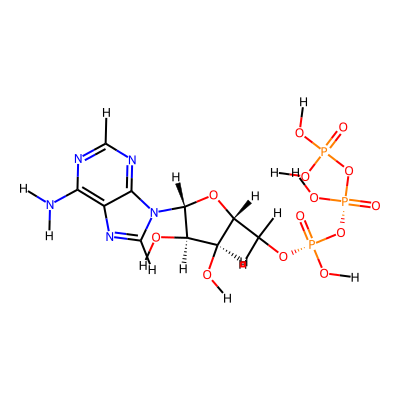

In [10]:
from rdkit.Chem import Draw

# Re-enrich ATP for visualization (re-uses the cached subprocess + index).
result = run_ccd_lookup(CcdLookupInput(identifiers=["ATP"]))
atp = result.ligands.fragments[0]

# 2D depiction. Draw.MolToImage strips explicit Hs and computes 2D coords
# automatically; the returned PIL image renders inline.
Draw.MolToImage(atp.mol, size=(400, 400))

> NOTE: The 3D viewer below renders locally (JupyterLab, VS Code) but not in GitHub previews.

In [11]:
# 3D: Fragment.visualize() generates a conformer and renders an interactive
# py3Dmol viewer. Works for `Ligands` collections too via
# `result.ligands.visualize()` (each fragment gets its own chain).
atp.visualize(width=400, height=400, style="stick")

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

## Export

`CcdLookupOutput` supports JSON export.

In [12]:
from pathlib import Path

output_dir = Path("./example_output")
output_dir.mkdir(exist_ok=True)
result.export(name="ccd_lookup_example", export_path=output_dir, file_format="json")
print(f"Wrote {output_dir}/ccd_lookup_example.json")

Wrote example_output/ccd_lookup_example.json
